# GARCH Project

## 1. Project Objective
This project studies volatility clustering in major stock indices using the GARCH model.
I download historical price data from Yahoo Finance, compute log returns, visualize volatility patterns, and estimate GARCH(1,1) models.

In [2]:
# # import Libraries
# import pandas as pd
# import numpy as np

# import matplotlib.pyplot as plt

# import yfinance as yf

# from arch import arch_model


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from arch import arch_model

from statsmodels.stats.diagnostic import acorr_ljungbox

## 2. Data Description
In this section, I download daily historical index prices from Yahoo Finance for four major global equity indices.

In [ ]:
# create a dictionary of tickers for major stock indices
tickers = {
    "S&P 500": "^GSPC",
    "EURO STOXX 50": "^STOXX50E",
    "Nikkei 225": "^N225",
    "FTSE 100": "^FTSE"
}


start_date = "2010-01-01"

# create an empty DataFrame to store the adj close prices
prices = pd.DataFrame()

# download the adjusted close prices for each index and store them in the DataFrame
for name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, auto_adjust=False, progress=False)
    prices[name] = df["Adj Close"]

prices.index.name = "Date"

prices.head()

,S&P 500,EURO STOXX 50,Nikkei 225,FTSE 100
Date,,,,
2010-01-04,1132.989990,3017.800049,10654.790039,5500.299805
2010-01-05,1136.520020,3012.360107,10681.830078,5522.500000
2010-01-06,1137.140015,3009.659912,10731.450195,5530.000000
2010-01-07,1141.689941,3007.340088,10681.660156,5526.700195
2010-01-08,1144.979980,3017.850098,10798.320312,5534.200195


## 3. Data Cleaning and Log Returns
In this section, I check for missing values and clean the price data to calculate log returns. Log returns are calculated instead of prices because GARCH models are designed to capture the time-varying volatility of returns. The returns are multiplied by 100 for easier interpretation and numerical stability.

In [4]:
# check missing values
prices.isna().sum()

# Remove rows with missing values
clean_prices = prices.dropna()

# Check the cleaned data
clean_prices.isna().sum()

S&P 500          0
EURO STOXX 50    0
Nikkei 225       0
FTSE 100         0
dtype: int64

In [5]:
# calculate log returns for each index
log_returns = np.log(clean_prices / clean_prices.shift(1)) * 100
# remove the first row (created by shift)
log_returns = log_returns.dropna()

# calculate summary statistics for log returns
summary_stats = pd.DataFrame({
    "Mean": log_returns.mean(),
    "Std Dev": log_returns.std(),
    "Min": log_returns.min(),
    "Max": log_returns.max(),
    "Skewness": log_returns.skew(),
    "Kurtosis": log_returns.kurtosis()
})

summary_stats.round(4)

,Mean,Std Dev,Min,Max,Skewness,Kurtosis
S&P 500,0.0499,1.1344,-12.7652,9.0895,-0.7073,13.1657
EURO STOXX 50,0.0192,1.3181,-13.2405,9.8466,-0.5231,7.5982
Nikkei 225,0.0475,1.4145,-13.2341,9.7366,-0.4079,6.8518
FTSE 100,0.0174,1.0123,-11.5117,8.6664,-0.7198,9.5023


## 4. Exploratory Data Analysis
In this section, I explore the characteristics of the return series through data visualization. Price movements, log returns, return distributions, and rolling volatility are examined to identify market trends, volatility clustering, and periods of financial stress before estimating the GARCH models. 

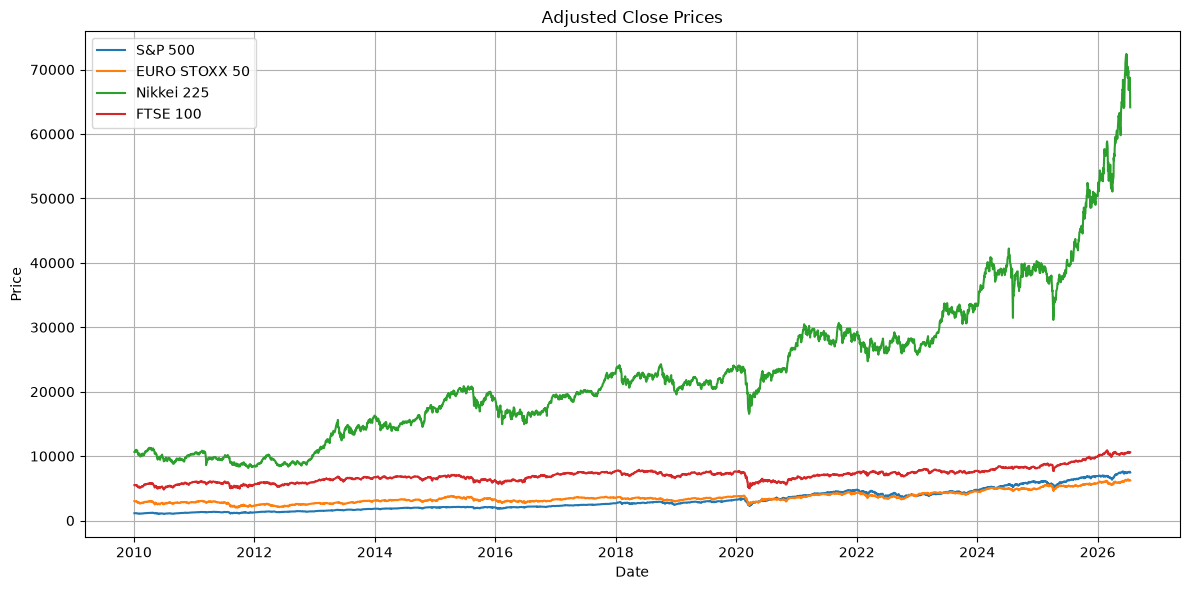

In [6]:
## price charts
plt.figure(figsize=(12, 6))
for col in clean_prices.columns:
    plt.plot(clean_prices.index, clean_prices[col], label=col)

plt.title("Adjusted Close Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend() 
plt.grid(True)
plt.tight_layout()
plt.show()



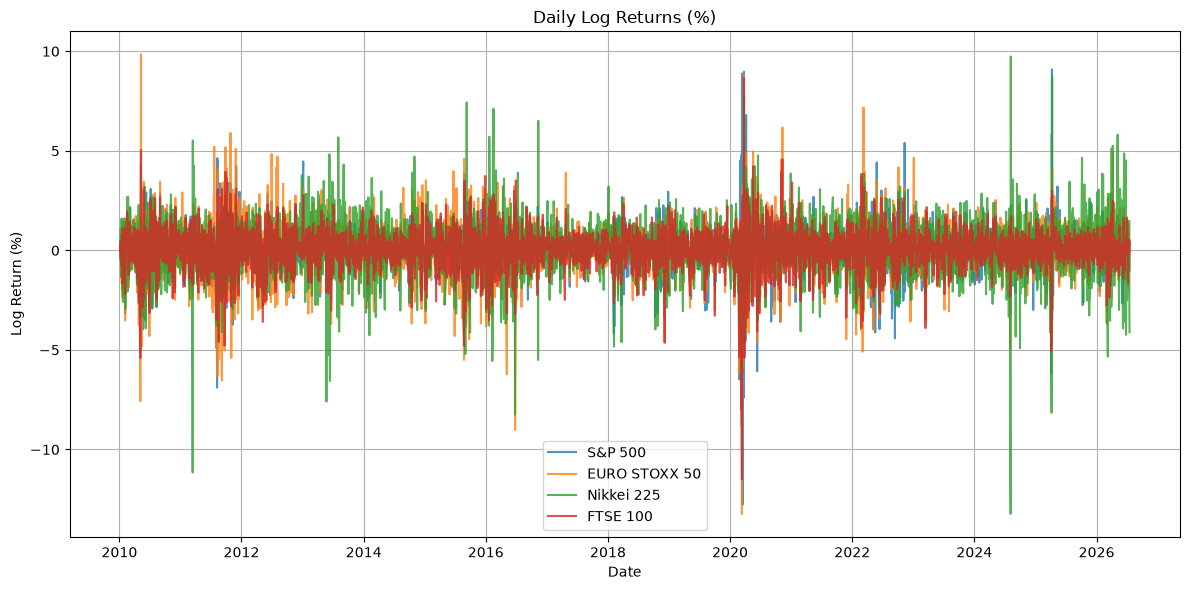

In [7]:
## return charts
plt.figure(figsize=(12, 6))
for col in log_returns.columns:
    plt.plot(log_returns.index, log_returns[col], label=col, alpha=0.8)

plt.title("Daily Log Returns (%)")
plt.xlabel("Date")
plt.ylabel("Log Return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


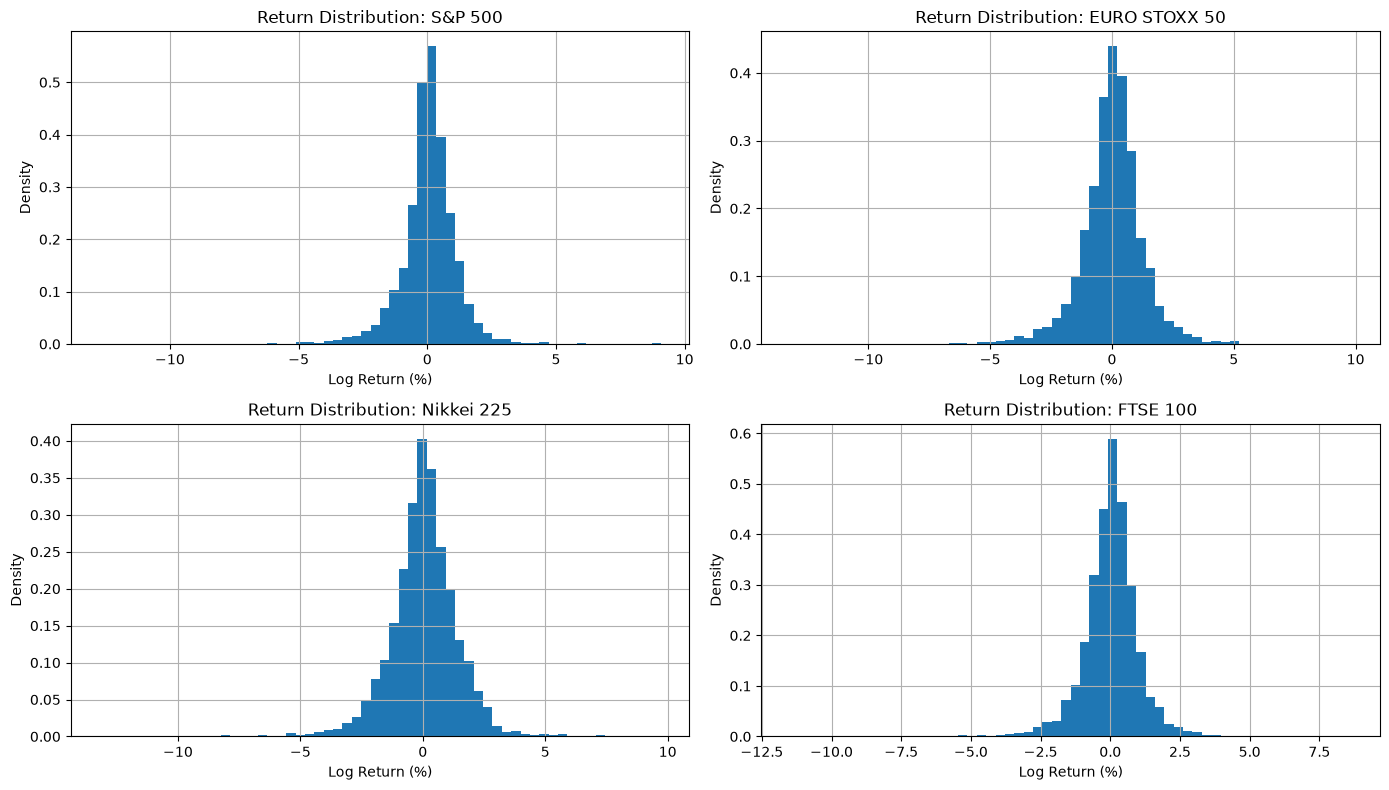

In [8]:
## return distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(log_returns.columns):
    axes[i].hist(log_returns[col].dropna(), bins=60, density=True)
    axes[i].set_title(f"Return Distribution: {col}")
    axes[i].set_xlabel("Log Return (%)") 
    axes[i].set_ylabel("Density")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

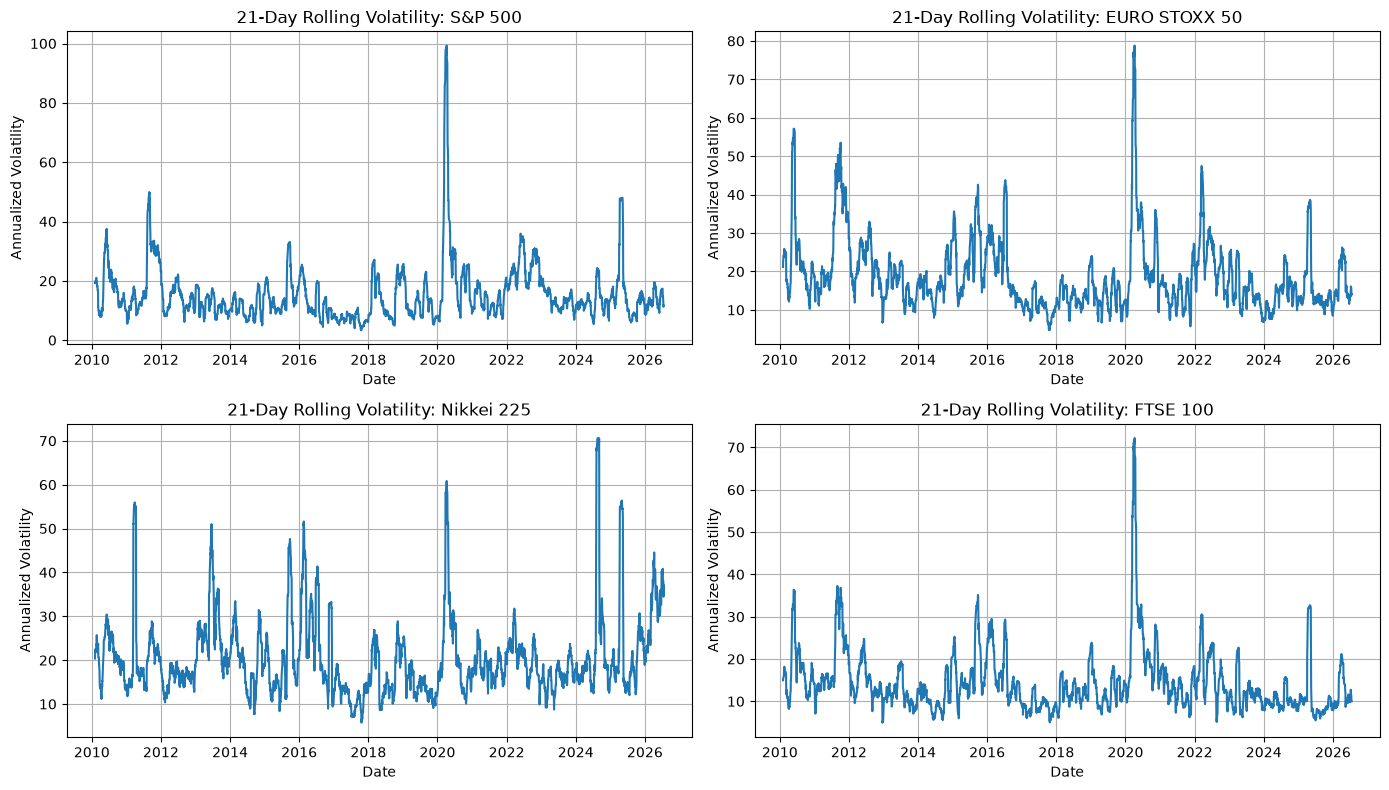

In [9]:
## rolling volatility
rolling_vol = log_returns.rolling(window=21).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(rolling_vol.columns):
    axes[i].plot(rolling_vol.index, rolling_vol[col])
    axes[i].set_title(f"21-Day Rolling Volatility: {col}")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Annualized Volatility")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


## 5. GARCH Model Estimation
In this section, I estimate GARCH(1,1) models for each equity index using both normal and Student-t error distributions. 

In [10]:
## fit GARCH(1,1) model
def fit_garch(series, dist="normal"):
    model = arch_model(
        series,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist=dist,
        rescale=False
    )
    result = model.fit(disp="off")
    return result


## Fit normal and Student-t for each index
all_results = {}

for col in log_returns.columns:
    s = log_returns[col].dropna()

    res_normal = fit_garch(s, dist="normal")
    res_t = fit_garch(s, dist="t")

    all_results[col] = {
        "normal": res_normal,
        "t": res_t
    }


## 6. Model Comparison
In this section, I compare the estimated GARCH models across the four equity indices. Model performance is evaluated using AIC and BIC, while volatility persistence is assessed through the alpha plus beta values. Residual diagnostic tests are also performed to examine whether the fitted models adequately capture the volatility dynamics.

In [11]:
## Compare AIC / BIC and parameters
rows = []

for col in log_returns.columns:
    res_n = all_results[col]["normal"]
    res_t = all_results[col]["t"]

    rows.append({
        "Index": col,
        "AIC_Normal": res_n.aic,
        "BIC_Normal": res_n.bic,
        "AIC_t": res_t.aic,
        "BIC_t": res_t.bic,
        "Best_Dist_By_AIC": "t" if res_t.aic < res_n.aic else "normal"
    })

comparison_table = pd.DataFrame(rows).set_index("Index")
comparison_table.round(4)

,AIC_Normal,BIC_Normal,AIC_t,BIC_t,Best_Dist_By_AIC
Index,,,,,
S&P 500,10098.6615,10123.6104,9785.0921,9816.2782,t
EURO STOXX 50,11851.4538,11876.4027,11557.6251,11588.8111,t
Nikkei 225,12594.9568,12619.9057,12429.9288,12461.1148,t
FTSE 100,9785.6053,9810.5542,9545.5758,9576.7619,t


In [12]:
## Table of omega, alpha, beta, alpha+beta
param_rows = []

for col in log_returns.columns:
    best_dist = "t" if comparison_table.loc[col, "Best_Dist_By_AIC"] == "t" else "normal"
    res = all_results[col][best_dist]
    p = res.params

    omega = p.get("omega", np.nan)
    alpha = p.get("alpha[1]", np.nan)
    beta = p.get("beta[1]", np.nan)
    persistence = alpha + beta

    param_rows.append({
        "Index": col,
        "Best_Dist": best_dist,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "alpha_plus_beta": persistence,
        "AIC": res.aic,
        "BIC": res.bic
    })

garch_param_table = pd.DataFrame(param_rows).set_index("Index")
garch_param_table.round(6)

,Best_Dist,omega,alpha,beta,alpha_plus_beta,AIC,BIC
Index,,,,,,,
S&P 500,t,0.028166,0.159517,0.830400,0.989917,9785.092080,9816.278153
EURO STOXX 50,t,0.047024,0.120809,0.858598,0.979407,11557.625068,11588.811142
Nikkei 225,t,0.084042,0.123724,0.837047,0.960771,12429.928756,12461.114829
FTSE 100,t,0.046829,0.143540,0.812897,0.956437,9545.575837,9576.761910


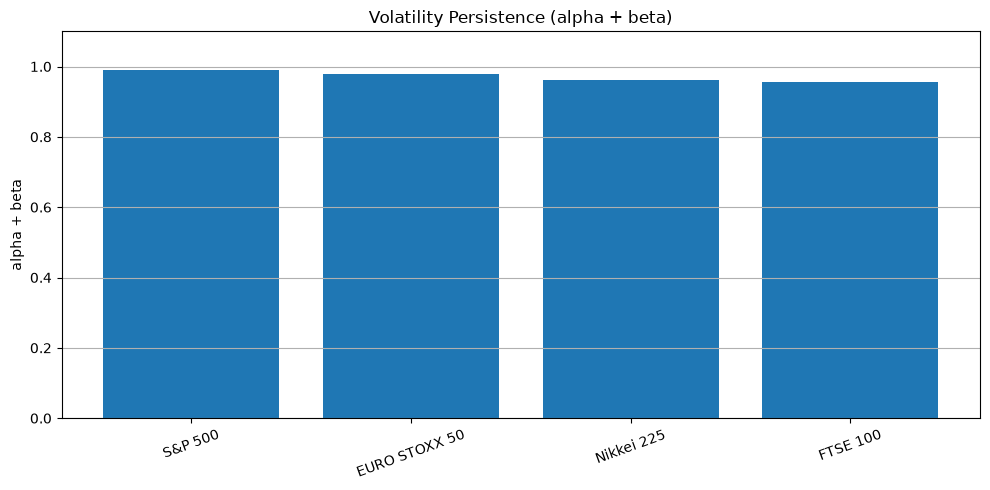

In [13]:
## Volatility persistence comparison chart
plt.figure(figsize=(10, 5))
plt.bar(garch_param_table.index, garch_param_table["alpha_plus_beta"])
plt.title("Volatility Persistence (alpha + beta)")
plt.ylabel("alpha + beta")
plt.ylim(0, 1.1)
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

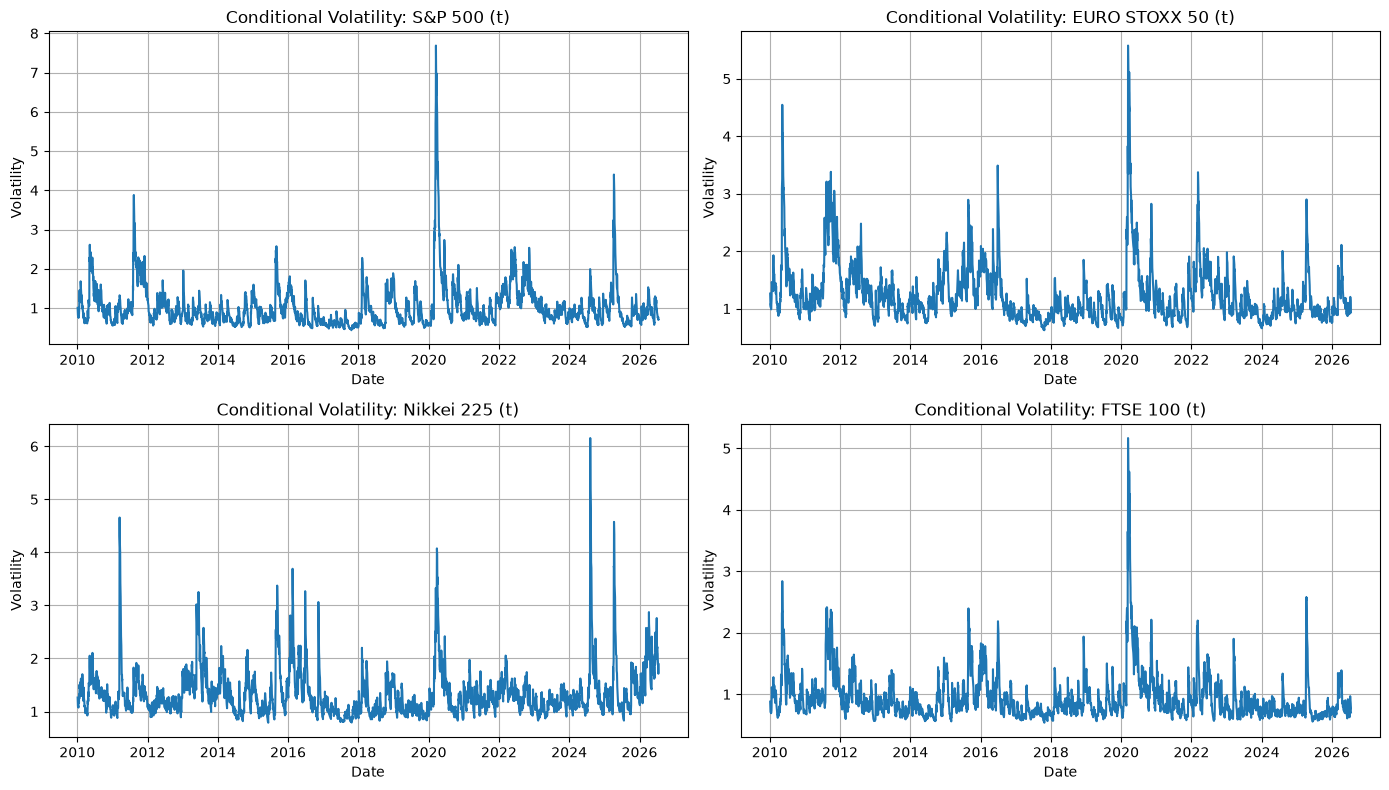

In [14]:
## Conditional volatility plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(log_returns.columns):
    best_dist = garch_param_table.loc[col, "Best_Dist"]
    res = all_results[col][best_dist]
    cond_vol = pd.Series(res.conditional_volatility, index=log_returns[col].dropna().index)

    axes[i].plot(cond_vol.index, cond_vol)
    axes[i].set_title(f"Conditional Volatility: {col} ({best_dist})")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Volatility")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [15]:
## Residual diagnostics
diagnostic_rows = []

for col in log_returns.columns:
    best_dist = garch_param_table.loc[col, "Best_Dist"]
    res = all_results[col][best_dist]

    std_resid = pd.Series(res.std_resid).dropna()
    lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    lb_sq_resid = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)

    diagnostic_rows.append({
        "Index": col,
        "Best_Dist": best_dist,
        "Ljung_Box_pvalue_Residuals_lag10": lb_resid["lb_pvalue"].iloc[0],
        "Ljung_Box_pvalue_Squared_Residuals_lag10": lb_sq_resid["lb_pvalue"].iloc[0]
    })

diagnostic_table = pd.DataFrame(diagnostic_rows).set_index("Index")
diagnostic_table.round(6)

,Best_Dist,Ljung_Box_pvalue_Residuals_lag10,Ljung_Box_pvalue_Squared_Residuals_lag10
Index,,,
S&P 500,t,0.290113,0.695529
EURO STOXX 50,t,0.768322,0.926162
Nikkei 225,t,0.914530,0.002165
FTSE 100,t,0.241100,0.671577


In [16]:
## Save results to files
summary_stats.to_csv("summary_statistics.csv")
comparison_table.to_csv("garch_aic_bic_comparison.csv")
garch_param_table.to_csv("garch_parameters.csv")
diagnostic_table.to_csv("garch_diagnostics.csv")

## 7. Conclusion

The GARCH(1,1) model successfully captures the volatility clustering observed in all four global equity indices.  
The Student-t specification consistently outperforms the normal distribution according to the information criteria, indicating the presence of heavy-tailed return distributions.  Among the four markets, the S&P 500 exhibits the highest volatility persistence, with an alpha-plus-beta value close to one, suggesting that volatility shocks decay slowly.  
All markets display substantial volatility spikes during the COVID-19 crisis, confirming that periods of financial stress are associated with elevated and persistent volatility.  
Finally, the residual diagnostic tests indicate that the fitted GARCH models adequately capture most serial dependence in the standardized residuals, although the Nikkei 225 still exhibits some remaining volatility dynamics. 
